# Model Explainability with SHAP (Task 3)

Built-in importance vs SHAP, a global summary plot, and force plots for a true positive, false positive and false negative.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


In [2]:
import shap
from src import config, preprocessing, modeling, explainability
fraud = pd.read_csv(config.PROCESSED_DIR/'fraud_data_processed.csv')
X, y = preprocessing.select_fraud_model_columns(fraud)
X_tr, X_te, y_tr, y_te = preprocessing.stratified_split(X, y)
try:
    pipe = modeling.load_model('fraud_data_best')
except Exception:
    est = modeling.make_xgboost(scale_pos_weight=modeling.imbalance_ratio(y_tr))
    pipe = preprocessing.make_plain_pipeline(preprocessing.build_fraud_preprocessor(X_tr), est).fit(X_tr, y_tr)
print('model ready')

model ready


## 1. Built-in feature importance (top 10)

,feature,importance
0,num__device_tx_count,0.271570
1,num__device_shared_users,0.100405
2,num__time_since_signup_hours,0.039284
3,num__time_since_signup_sec,0.020044
4,cat__country_United Kingdom,0.007467
5,cat__source_Ads,0.007148
6,cat__source_Direct,0.007136
7,cat__country_Canada,0.006940
8,cat__country_South Africa,0.006739
9,cat__country_China,0.006631


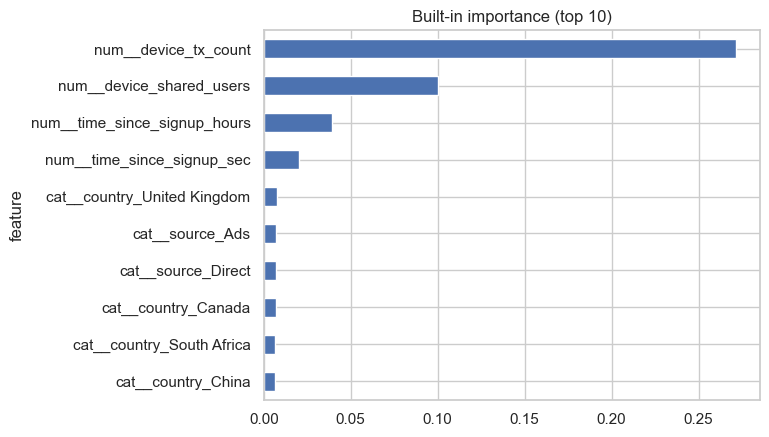

In [3]:
imp = explainability.builtin_importance(pipe, top_n=10)
display(imp)
imp.set_index('feature')['importance'].iloc[::-1].plot.barh(title='Built-in importance (top 10)')
plt.savefig(config.FIGURES_DIR/'builtin_importance.png', dpi=120, bbox_inches='tight'); plt.show()

## 2. SHAP global summary

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


 32%|======              | 639/2000 [00:11<00:23]       

 35%|=======             | 698/2000 [00:12<00:22]       

 38%|========            | 753/2000 [00:13<00:21]       

 41%|========            | 813/2000 [00:14<00:20]       

 44%|=========           | 870/2000 [00:15<00:19]       

 46%|=========           | 930/2000 [00:16<00:18]       

 49%|==========          | 988/2000 [00:17<00:17]       

 52%|==========          | 1042/2000 [00:18<00:16]       

 55%|===========         | 1102/2000 [00:19<00:15]       

 58%|============        | 1159/2000 [00:20<00:14]       

 60%|============        | 1208/2000 [00:21<00:13]       

 63%|=============       | 1257/2000 [00:22<00:13]       

 66%|=============       | 1312/2000 [00:23<00:12]       

 68%|==============      | 1363/2000 [00:24<00:11]       

 71%|==============      | 1411/2000 [00:25<00:10]       

 73%|===============     | 1466/2000 [00:26<00:09]       

 76%|===============     | 1510/2000 [00:27<00:08]       

 78%|================    | 1567/2000 [00:28<00:07]       

 81%|================    | 1621/2000 [00:29<00:06]       

 84%|=================   | 1682/2000 [00:30<00:05]       

 87%|=================   | 1745/2000 [00:31<00:04]       

 91%|==================  | 1811/2000 [00:32<00:03]       

 94%|=================== | 1878/2000 [00:33<00:02]       

 97%|=================== | 1944/2000 [00:34<00:00]       

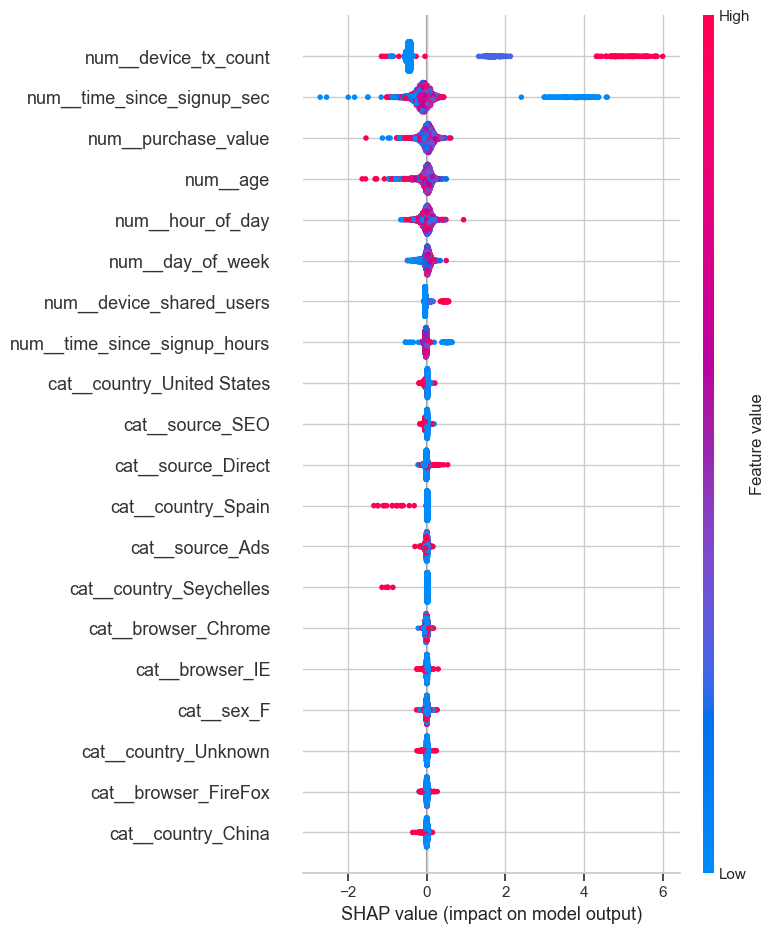

In [4]:
explainer, shap_values, X_trans = explainability.compute_shap_values(pipe, X_te.sample(min(2000, len(X_te)), random_state=42))
shap.summary_plot(shap_values, X_trans, show=False)
plt.savefig(config.FIGURES_DIR/'shap_summary.png', dpi=120, bbox_inches='tight'); plt.show()

## 3. Force plots: TP, FP, FN
We locate one correctly-caught fraud, one false alarm, and one missed fraud.

In [5]:
proba = pipe.predict_proba(X_te)[:,1]; pred = (proba>=0.5).astype(int)
yte = y_te.reset_index(drop=True); pred = pd.Series(pred); proba = pd.Series(proba)
tp = pred[(pred==1)&(yte==1)].index[:1]
fp = pred[(pred==1)&(yte==0)].index[:1]
fn = pred[(pred==0)&(yte==1)].index[:1]
print('TP idx', list(tp), '| FP idx', list(fp), '| FN idx', list(fn))

TP idx [2] | FP idx [3] | FN idx [25]


In [6]:
Xte_named = explainability.transform_for_shap(pipe, X_te).reset_index(drop=True)
sv_all = explainer(Xte_named)
shap.initjs()

  2%|                   | 681/30223 [00:11<07:57]       

  2%|                   | 746/30223 [00:12<07:54]       

  3%|=                   | 810/30223 [00:13<07:52]       

  3%|=                   | 869/30223 [00:14<07:52]       

  3%|=                   | 951/30223 [00:15<07:41]       

  3%|=                   | 1046/30223 [00:16<07:26]       

  4%|=                   | 1138/30223 [00:17<07:14]       

  4%|=                   | 1234/30223 [00:18<07:02]       

  4%|=                   | 1328/30223 [00:19<06:53]       

  5%|=                   | 1422/30223 [00:20<06:45]       

  5%|=                   | 1505/30223 [00:21<06:40]       

  5%|=                   | 1585/30223 [00:22<06:37]       

  6%|=                   | 1666/30223 [00:23<06:34]       

  6%|=                   | 1745/30223 [00:24<06:31]       

  6%|=                   | 1824/30223 [00:25<06:29]       

  6%|=                   | 1905/30223 [00:26<06:26]       

  7%|=                   | 1981/30223 [00:27<06:24]       

  7%|=                   | 2059/30223 [00:28<06:22]       

  7%|=                   | 2141/30223 [00:29<06:20]       

  7%|=                   | 2224/30223 [00:30<06:17]       

  8%|==                  | 2302/30223 [00:31<06:15]       

  8%|==                  | 2383/30223 [00:32<06:13]       

  8%|==                  | 2466/30223 [00:33<06:11]       

  8%|==                  | 2548/30223 [00:34<06:09]       

  9%|==                  | 2630/30223 [00:35<06:07]       

  9%|==                  | 2712/30223 [00:36<06:05]       

  9%|==                  | 2789/30223 [00:37<06:03]       

  9%|==                  | 2869/30223 [00:38<06:02]       

 10%|==                  | 2949/30223 [00:39<06:00]       

 10%|==                  | 3029/30223 [00:40<05:59]       

 10%|==                  | 3104/30223 [00:41<05:58]       

 11%|==                  | 3186/30223 [00:42<05:56]       

 11%|==                  | 3266/30223 [00:43<05:54]       

 11%|==                  | 3347/30223 [00:44<05:53]       

 11%|==                  | 3416/30223 [00:45<05:53]       

 12%|==                  | 3497/30223 [00:46<05:51]       

 12%|==                  | 3579/30223 [00:47<05:49]       

 12%|==                  | 3658/30223 [00:48<05:48]       

 12%|==                  | 3720/30223 [00:49<05:49]       

 13%|===                 | 3788/30223 [00:50<05:48]       

 13%|===                 | 3853/30223 [00:51<05:49]       

 13%|===                 | 3928/30223 [00:52<05:48]       

 13%|===                 | 3995/30223 [00:53<05:47]       

 13%|===                 | 4065/30223 [00:54<05:47]       

 14%|===                 | 4142/30223 [00:55<05:46]       

 14%|===                 | 4224/30223 [00:56<05:44]       

 14%|===                 | 4307/30223 [00:57<05:42]       

 15%|===                 | 4390/30223 [00:58<05:41]       

 15%|===                 | 4471/30223 [00:59<05:39]       

 15%|===                 | 4556/30223 [01:00<05:38]       

 15%|===                 | 4638/30223 [01:01<05:36]       

 16%|===                 | 4713/30223 [01:02<05:35]       

 16%|===                 | 4793/30223 [01:03<05:34]       

 16%|===                 | 4873/30223 [01:04<05:32]       

 16%|===                 | 4953/30223 [01:05<05:31]       

 17%|===                 | 5019/30223 [01:06<05:31]       

 17%|===                 | 5090/30223 [01:07<05:30]       

 17%|===                 | 5170/30223 [01:08<05:29]       

 17%|===                 | 5251/30223 [01:09<05:28]       

 18%|====                | 5334/30223 [01:10<05:26]       

 18%|====                | 5413/30223 [01:11<05:25]       

 18%|====                | 5495/30223 [01:12<05:24]       

 18%|====                | 5577/30223 [01:13<05:22]       

 19%|====                | 5658/30223 [01:14<05:21]       

 19%|====                | 5739/30223 [01:15<05:19]       

 19%|====                | 5819/30223 [01:16<05:18]       

 20%|====                | 5899/30223 [01:17<05:17]       

 20%|====                | 5981/30223 [01:18<05:16]       

 20%|====                | 6056/30223 [01:19<05:15]       

 20%|====                | 6132/30223 [01:20<05:14]       

 21%|====                | 6212/30223 [01:21<05:13]       

 21%|====                | 6293/30223 [01:22<05:11]       

 21%|====                | 6374/30223 [01:23<05:10]       

 21%|====                | 6453/30223 [01:24<05:09]       

 22%|====                | 6533/30223 [01:25<05:08]       

 22%|====                | 6606/30223 [01:26<05:07]       

 22%|====                | 6675/30223 [01:27<05:06]       

 22%|====                | 6753/30223 [01:28<05:05]       

 23%|=====               | 6833/30223 [01:29<05:04]       

 23%|=====               | 6915/30223 [01:30<05:03]       

 23%|=====               | 6996/30223 [01:31<05:02]       

 23%|=====               | 7077/30223 [01:32<05:00]       

 24%|=====               | 7158/30223 [01:33<04:59]       

 24%|=====               | 7240/30223 [01:34<04:58]       

 24%|=====               | 7321/30223 [01:35<04:57]       

 24%|=====               | 7399/30223 [01:36<04:56]       

 25%|=====               | 7477/30223 [01:37<04:55]       

 25%|=====               | 7560/30223 [01:38<04:53]       

 25%|=====               | 7644/30223 [01:39<04:52]       

 26%|=====               | 7724/30223 [01:40<04:51]       

 26%|=====               | 7805/30223 [01:41<04:50]       

 26%|=====               | 7887/30223 [01:42<04:48]       

 26%|=====               | 7972/30223 [01:43<04:47]       

 27%|=====               | 8048/30223 [01:44<04:46]       

 27%|=====               | 8130/30223 [01:45<04:45]       

 27%|=====               | 8212/30223 [01:46<04:44]       

 27%|=====               | 8294/30223 [01:47<04:42]       

 28%|======              | 8373/30223 [01:48<04:41]       

 28%|======              | 8455/30223 [01:49<04:40]       

 28%|======              | 8536/30223 [01:50<04:39]       

 29%|======              | 8619/30223 [01:51<04:38]       

 29%|======              | 8700/30223 [01:52<04:37]       

 29%|======              | 8778/30223 [01:53<04:36]       

 29%|======              | 8858/30223 [01:54<04:34]       

 30%|======              | 8937/30223 [01:55<04:33]       

 30%|======              | 9018/30223 [01:56<04:32]       

 30%|======              | 9100/30223 [01:57<04:31]       

 30%|======              | 9183/30223 [01:58<04:30]       

 31%|======              | 9264/30223 [01:59<04:29]       

 31%|======              | 9346/30223 [02:00<04:28]       

 31%|======              | 9426/30223 [02:01<04:26]       

 31%|======              | 9492/30223 [02:02<04:26]       

 32%|======              | 9570/30223 [02:03<04:25]       

 32%|======              | 9651/30223 [02:04<04:24]       

 32%|======              | 9734/30223 [02:05<04:23]       

 32%|======              | 9803/30223 [02:06<04:22]       

 33%|=======             | 9874/30223 [02:07<04:21]       

 33%|=======             | 9956/30223 [02:08<04:20]       

 33%|=======             | 10029/30223 [02:09<04:19]       

 33%|=======             | 10110/30223 [02:10<04:18]       

 34%|=======             | 10182/30223 [02:11<04:17]       

 34%|=======             | 10259/30223 [02:12<04:16]       

 34%|=======             | 10337/30223 [02:13<04:15]       

 34%|=======             | 10419/30223 [02:14<04:14]       

 35%|=======             | 10501/30223 [02:15<04:13]       

 35%|=======             | 10582/30223 [02:16<04:12]       

 35%|=======             | 10664/30223 [02:17<04:11]       

 36%|=======             | 10746/30223 [02:18<04:10]       

 36%|=======             | 10820/30223 [02:19<04:09]       

 36%|=======             | 10900/30223 [02:20<04:08]       

 36%|=======             | 10983/30223 [02:21<04:07]       

 37%|=======             | 11064/30223 [02:22<04:05]       

 37%|=======             | 11144/30223 [02:23<04:04]       

 37%|=======             | 11228/30223 [02:24<04:03]       

 37%|=======             | 11310/30223 [02:25<04:02]       

 38%|========            | 11392/30223 [02:26<04:01]       

 38%|========            | 11470/30223 [02:27<04:00]       

 38%|========            | 11549/30223 [02:28<03:59]       

 38%|========            | 11630/30223 [02:29<03:58]       

 39%|========            | 11713/30223 [02:30<03:57]       

 39%|========            | 11793/30223 [02:31<03:55]       

 39%|========            | 11869/30223 [02:32<03:55]       

 40%|========            | 11949/30223 [02:33<03:53]       

 40%|========            | 12031/30223 [02:34<03:52]       

 40%|========            | 12111/30223 [02:35<03:51]       

 40%|========            | 12195/30223 [02:36<03:50]       

 41%|========            | 12275/30223 [02:37<03:49]       

 41%|========            | 12357/30223 [02:38<03:48]       

 41%|========            | 12436/30223 [02:39<03:47]       

 41%|========            | 12515/30223 [02:40<03:46]       

 42%|========            | 12597/30223 [02:41<03:45]       

 42%|========            | 12674/30223 [02:42<03:44]       

 42%|========            | 12744/30223 [02:43<03:43]       

 42%|========            | 12824/30223 [02:44<03:42]       

 43%|=========           | 12908/30223 [02:45<03:41]       

 43%|=========           | 12990/30223 [02:46<03:40]       

 43%|=========           | 13069/30223 [02:47<03:39]       

 44%|=========           | 13152/30223 [02:48<03:38]       

 44%|=========           | 13232/30223 [02:49<03:37]       

 44%|=========           | 13312/30223 [02:50<03:35]       

 44%|=========           | 13392/30223 [02:51<03:34]       

 45%|=========           | 13475/30223 [02:52<03:33]       

 45%|=========           | 13554/30223 [02:53<03:32]       

 45%|=========           | 13634/30223 [02:54<03:31]       

 45%|=========           | 13715/30223 [02:55<03:30]       

 46%|=========           | 13796/30223 [02:56<03:29]       

 46%|=========           | 13876/30223 [02:57<03:28]       

 46%|=========           | 13960/30223 [02:58<03:27]       

 46%|=========           | 14039/30223 [02:59<03:26]       

 47%|=========           | 14121/30223 [03:00<03:25]       

 47%|=========           | 14203/30223 [03:01<03:24]       

 47%|=========           | 14283/30223 [03:02<03:23]       

 48%|==========          | 14365/30223 [03:03<03:22]       

 48%|==========          | 14447/30223 [03:04<03:20]       

 48%|==========          | 14528/30223 [03:05<03:19]       

 48%|==========          | 14595/30223 [03:06<03:19]       

 49%|==========          | 14665/30223 [03:07<03:18]       

 49%|==========          | 14740/30223 [03:08<03:17]       

 49%|==========          | 14819/30223 [03:09<03:16]       

 49%|==========          | 14901/30223 [03:10<03:15]       

 50%|==========          | 14983/30223 [03:11<03:14]       

 50%|==========          | 15065/30223 [03:12<03:13]       

 50%|==========          | 15148/30223 [03:13<03:12]       

 50%|==========          | 15229/30223 [03:14<03:11]       

 51%|==========          | 15310/30223 [03:15<03:09]       

 51%|==========          | 15391/30223 [03:16<03:08]       

 51%|==========          | 15469/30223 [03:17<03:07]       

 51%|==========          | 15552/30223 [03:18<03:06]       

 52%|==========          | 15627/30223 [03:19<03:05]       

 52%|==========          | 15700/30223 [03:20<03:05]       

 52%|==========          | 15780/30223 [03:21<03:03]       

 52%|==========          | 15861/30223 [03:22<03:02]       

 53%|===========         | 15945/30223 [03:23<03:01]       

 53%|===========         | 16013/30223 [03:24<03:01]       

 53%|===========         | 16094/30223 [03:25<02:59]       

 54%|===========         | 16175/30223 [03:26<02:58]       

 54%|===========         | 16252/30223 [03:27<02:57]       

 54%|===========         | 16332/30223 [03:28<02:56]       

 54%|===========         | 16412/30223 [03:29<02:55]       

 55%|===========         | 16493/30223 [03:30<02:54]       

 55%|===========         | 16574/30223 [03:31<02:53]       

 55%|===========         | 16651/30223 [03:32<02:52]       

 55%|===========         | 16731/30223 [03:33<02:51]       

 56%|===========         | 16802/30223 [03:34<02:50]       

 56%|===========         | 16864/30223 [03:35<02:50]       

 56%|===========         | 16944/30223 [03:36<02:49]       

 56%|===========         | 17025/30223 [03:37<02:48]       

 57%|===========         | 17104/30223 [03:38<02:47]       

 57%|===========         | 17187/30223 [03:39<02:46]       

 57%|===========         | 17264/30223 [03:40<02:45]       

 57%|===========         | 17344/30223 [03:41<02:44]       

 58%|============        | 17425/30223 [03:42<02:43]       

 58%|============        | 17503/30223 [03:43<02:42]       

 58%|============        | 17583/30223 [03:44<02:41]       

 58%|============        | 17662/30223 [03:45<02:40]       

 59%|============        | 17741/30223 [03:46<02:39]       

 59%|============        | 17791/30223 [03:47<02:38]       

 59%|============        | 17858/30223 [03:48<02:37]       

 59%|============        | 17926/30223 [03:49<02:37]       

 60%|============        | 17997/30223 [03:50<02:36]       

 60%|============        | 18077/30223 [03:51<02:35]       

 60%|============        | 18145/30223 [03:52<02:34]       

 60%|============        | 18226/30223 [03:53<02:33]       

 61%|============        | 18306/30223 [03:54<02:32]       

 61%|============        | 18388/30223 [03:55<02:31]       

 61%|============        | 18468/30223 [03:56<02:30]       

 61%|============        | 18551/30223 [03:57<02:29]       

 62%|============        | 18633/30223 [03:58<02:28]       

 62%|============        | 18713/30223 [03:59<02:27]       

 62%|============        | 18795/30223 [04:00<02:25]       

 62%|============        | 18876/30223 [04:01<02:24]       

 63%|=============       | 18956/30223 [04:02<02:23]       

 63%|=============       | 19032/30223 [04:03<02:22]       

 63%|=============       | 19110/30223 [04:04<02:21]       

 63%|=============       | 19178/30223 [04:05<02:21]       

 64%|=============       | 19244/30223 [04:06<02:20]       

 64%|=============       | 19308/30223 [04:07<02:19]       

 64%|=============       | 19375/30223 [04:08<02:18]       

 64%|=============       | 19448/30223 [04:09<02:17]       

 65%|=============       | 19528/30223 [04:10<02:16]       

 65%|=============       | 19609/30223 [04:11<02:15]       

 65%|=============       | 19688/30223 [04:12<02:14]       

 65%|=============       | 19772/30223 [04:13<02:13]       

 66%|=============       | 19852/30223 [04:14<02:12]       

 66%|=============       | 19932/30223 [04:15<02:11]       

 66%|=============       | 19991/30223 [04:16<02:11]       

 66%|=============       | 20060/30223 [04:17<02:10]       

 67%|=============       | 20116/30223 [04:18<02:09]       

 67%|=============       | 20167/30223 [04:19<02:09]       

 67%|=============       | 20225/30223 [04:20<02:08]       

 67%|=============       | 20283/30223 [04:21<02:07]       

 67%|=============       | 20329/30223 [04:22<02:07]       

 67%|=============       | 20383/30223 [04:23<02:06]       

 68%|==============      | 20441/30223 [04:24<02:06]       

 68%|==============      | 20505/30223 [04:25<02:05]       

 68%|==============      | 20584/30223 [04:26<02:04]       

 68%|==============      | 20659/30223 [04:27<02:03]       

 69%|==============      | 20738/30223 [04:28<02:02]       

 69%|==============      | 20817/30223 [04:29<02:01]       

 69%|==============      | 20899/30223 [04:30<02:00]       

 69%|==============      | 20981/30223 [04:31<01:59]       

 70%|==============      | 21060/30223 [04:32<01:58]       

 70%|==============      | 21141/30223 [04:33<01:57]       

 70%|==============      | 21221/30223 [04:34<01:56]       

 70%|==============      | 21303/30223 [04:35<01:55]       

 71%|==============      | 21386/30223 [04:36<01:54]       

 71%|==============      | 21466/30223 [04:37<01:53]       

 71%|==============      | 21549/30223 [04:38<01:51]       

 72%|==============      | 21630/30223 [04:39<01:50]       

 72%|==============      | 21712/30223 [04:40<01:49]       

 72%|==============      | 21794/30223 [04:41<01:48]       

 72%|==============      | 21869/30223 [04:42<01:47]       

 73%|===============     | 21929/30223 [04:43<01:47]       

 73%|===============     | 21997/30223 [04:44<01:46]       

 73%|===============     | 22063/30223 [04:45<01:45]       

 73%|===============     | 22124/30223 [04:46<01:44]       

 73%|===============     | 22198/30223 [04:47<01:43]       

 74%|===============     | 22269/30223 [04:48<01:42]       

 74%|===============     | 22351/30223 [04:49<01:41]       

 74%|===============     | 22433/30223 [04:50<01:40]       

 74%|===============     | 22512/30223 [04:51<01:39]       

 75%|===============     | 22594/30223 [04:52<01:38]       

 75%|===============     | 22674/30223 [04:53<01:37]       

 75%|===============     | 22755/30223 [04:54<01:36]       

 76%|===============     | 22837/30223 [04:55<01:35]       

 76%|===============     | 22916/30223 [04:56<01:34]       

 76%|===============     | 22995/30223 [04:57<01:33]       

 76%|===============     | 23075/30223 [04:58<01:32]       

 77%|===============     | 23158/30223 [04:59<01:31]       

 77%|===============     | 23238/30223 [05:00<01:30]       

 77%|===============     | 23319/30223 [05:01<01:29]       

 77%|===============     | 23399/30223 [05:02<01:28]       

 78%|================    | 23481/30223 [05:03<01:26]       

 78%|================    | 23555/30223 [05:04<01:26]       

 78%|================    | 23630/30223 [05:05<01:25]       

 78%|================    | 23687/30223 [05:06<01:24]       

 79%|================    | 23748/30223 [05:07<01:23]       

 79%|================    | 23828/30223 [05:08<01:22]       

 79%|================    | 23908/30223 [05:09<01:21]       

 79%|================    | 23991/30223 [05:10<01:20]       

 80%|================    | 24069/30223 [05:11<01:19]       

 80%|================    | 24148/30223 [05:12<01:18]       

 80%|================    | 24222/30223 [05:13<01:17]       

 80%|================    | 24301/30223 [05:14<01:16]       

 81%|================    | 24383/30223 [05:15<01:15]       

 81%|================    | 24461/30223 [05:16<01:14]       

 81%|================    | 24544/30223 [05:17<01:13]       

 81%|================    | 24626/30223 [05:18<01:12]       

 82%|================    | 24702/30223 [05:19<01:11]       

 82%|================    | 24781/30223 [05:20<01:10]       

 82%|================    | 24859/30223 [05:21<01:09]       

 83%|=================   | 24941/30223 [05:22<01:08]       

 83%|=================   | 25019/30223 [05:23<01:07]       

 83%|=================   | 25097/30223 [05:24<01:06]       

 83%|=================   | 25177/30223 [05:25<01:05]       

 84%|=================   | 25258/30223 [05:26<01:04]       

 84%|=================   | 25326/30223 [05:27<01:03]       

 84%|=================   | 25404/30223 [05:28<01:02]       

 84%|=================   | 25486/30223 [05:29<01:01]       

 85%|=================   | 25568/30223 [05:30<01:00]       

 85%|=================   | 25649/30223 [05:31<00:59]       

 85%|=================   | 25729/30223 [05:32<00:57]       

 85%|=================   | 25779/30223 [05:33<00:57]       

 85%|=================   | 25835/30223 [05:34<00:56]       

 86%|=================   | 25901/30223 [05:35<00:55]       

 86%|=================   | 25978/30223 [05:36<00:54]       

 86%|=================   | 26057/30223 [05:37<00:53]       

 86%|=================   | 26126/30223 [05:38<00:53]       

 87%|=================   | 26200/30223 [05:39<00:52]       

 87%|=================   | 26275/30223 [05:40<00:51]       

 87%|=================   | 26353/30223 [05:41<00:50]       

 87%|=================   | 26428/30223 [05:42<00:49]       

 88%|==================  | 26501/30223 [05:43<00:48]       

 88%|==================  | 26570/30223 [05:44<00:47]       

 88%|==================  | 26646/30223 [05:45<00:46]       

 88%|==================  | 26721/30223 [05:46<00:45]       

 89%|==================  | 26797/30223 [05:47<00:44]       

 89%|==================  | 26870/30223 [05:48<00:43]       

 89%|==================  | 26944/30223 [05:49<00:42]       

 89%|==================  | 27021/30223 [05:50<00:41]       

 90%|==================  | 27099/30223 [05:51<00:40]       

 90%|==================  | 27177/30223 [05:52<00:39]       

 90%|==================  | 27258/30223 [05:53<00:38]       

 90%|==================  | 27337/30223 [05:54<00:37]       

 91%|==================  | 27416/30223 [05:55<00:36]       

 91%|==================  | 27492/30223 [05:56<00:35]       

 91%|==================  | 27573/30223 [05:57<00:34]       

 91%|==================  | 27653/30223 [05:58<00:33]       

 92%|==================  | 27730/30223 [05:59<00:32]       

 92%|==================  | 27812/30223 [06:00<00:31]       

 92%|==================  | 27891/30223 [06:01<00:30]       

 93%|=================== | 27967/30223 [06:02<00:29]       

 93%|=================== | 28043/30223 [06:03<00:28]       

 93%|=================== | 28104/30223 [06:04<00:27]       

 93%|=================== | 28137/30223 [06:05<00:27]       

 93%|=================== | 28173/30223 [06:06<00:26]       

 93%|=================== | 28220/30223 [06:07<00:26]       

 94%|=================== | 28291/30223 [06:08<00:25]       

 94%|=================== | 28363/30223 [06:09<00:24]       

 94%|=================== | 28430/30223 [06:10<00:23]       

 94%|=================== | 28502/30223 [06:11<00:22]       

 95%|=================== | 28563/30223 [06:12<00:21]       

 95%|=================== | 28633/30223 [06:13<00:20]       

 95%|=================== | 28707/30223 [06:14<00:19]       

 95%|=================== | 28783/30223 [06:15<00:18]       

 95%|=================== | 28854/30223 [06:16<00:17]       

 96%|=================== | 28926/30223 [06:17<00:16]       

 96%|=================== | 29001/30223 [06:18<00:15]       

 96%|=================== | 29070/30223 [06:19<00:15]       

 96%|=================== | 29134/30223 [06:20<00:14]       

 97%|=================== | 29196/30223 [06:21<00:13]       

 97%|=================== | 29264/30223 [06:22<00:12]       

 97%|=================== | 29332/30223 [06:23<00:11]       

 97%|=================== | 29400/30223 [06:24<00:10]       

 98%|===================| 29474/30223 [06:25<00:09]       

 98%|===================| 29541/30223 [06:26<00:08]       

 98%|===================| 29609/30223 [06:27<00:08]       

 98%|===================| 29679/30223 [06:28<00:07]       

 98%|===================| 29749/30223 [06:29<00:06]       

 99%|===================| 29829/30223 [06:30<00:05]       

 99%|===================| 29900/30223 [06:31<00:04]       

 99%|===================| 29977/30223 [06:32<00:03]       

 99%|===================| 30056/30223 [06:33<00:02]       

100%|===================| 30113/30223 [06:34<00:01]       

100%|===================| 30177/30223 [06:35<00:00]       

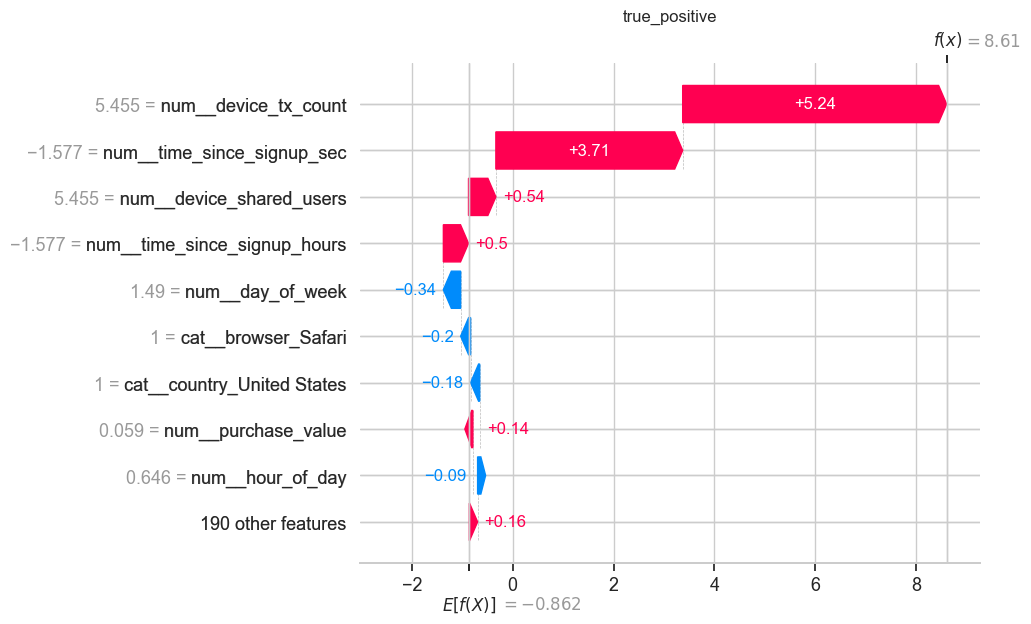

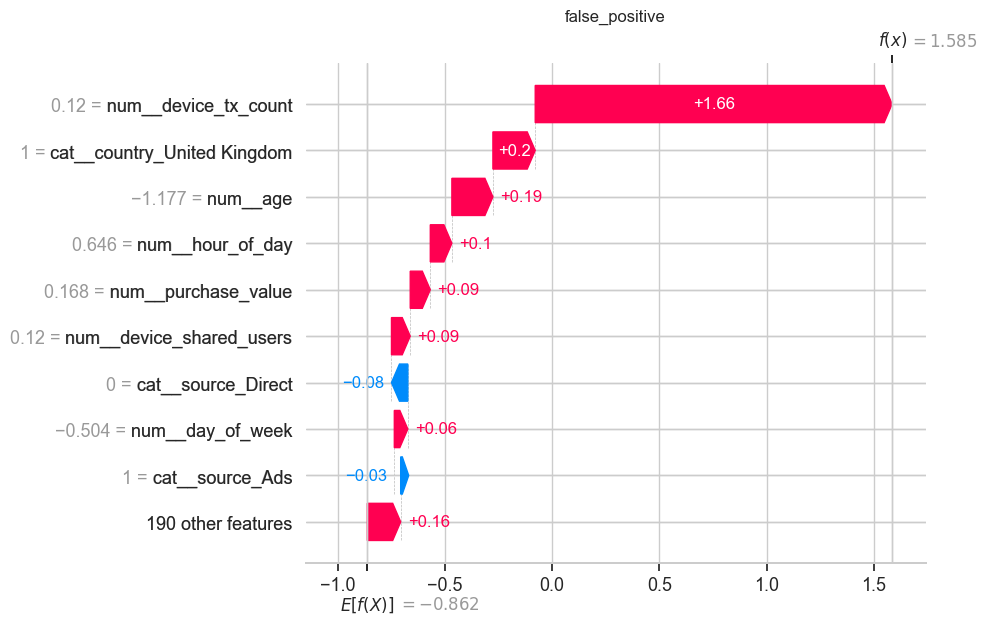

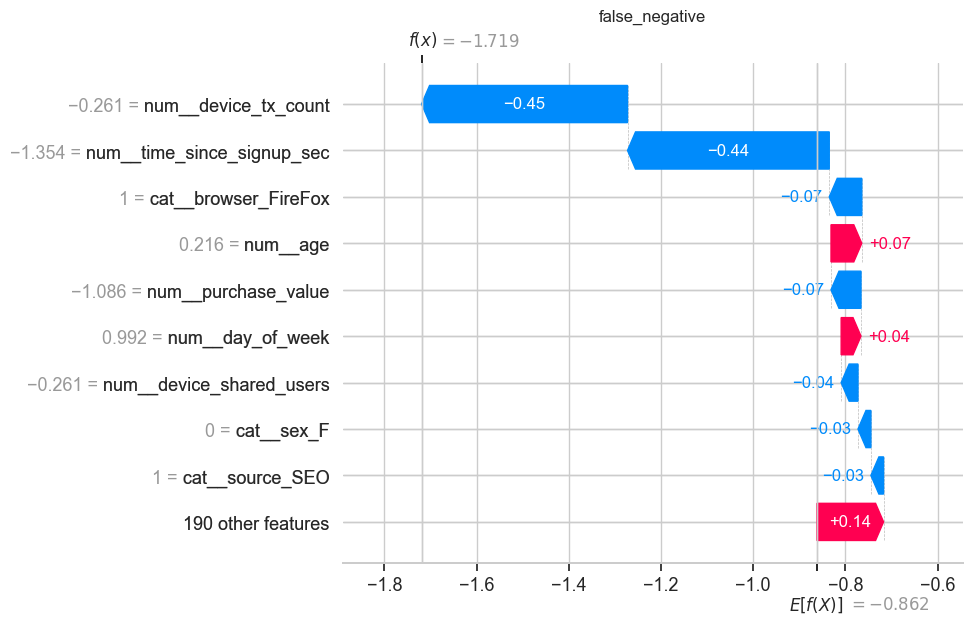

In [7]:
def force(i, title):
    if len(i)==0:
        print('no example for', title); return
    idx=i[0]
    shap.plots.waterfall(sv_all[idx], show=False)
    plt.title(title); plt.savefig(config.FIGURES_DIR/f'shap_{title}.png', dpi=120, bbox_inches='tight'); plt.show()
force(tp, 'true_positive')
force(fp, 'false_positive')
force(fn, 'false_negative')

## 4. Interpretation & business recommendations

**Top fraud drivers (expected):** `time_since_signup`, transaction velocity (`sec_since_prev_user_tx`, `device_shared_users`), `purchase_value`, `hour_of_day`, and certain `source`/`country` values.

**Built-in vs SHAP:** built-in importance ranks features by split gain (global, direction-agnostic); SHAP shows *direction* and *per-prediction* contribution - e.g. a *small* `time_since_signup` pushes a prediction **towards fraud**.

**Recommendations**
1. **Step-up verification for purchases made shortly after signup** (small `time_since_signup`) - the dominant SHAP driver.
2. **Flag device/IP velocity**: many users per device or rapid repeat purchases (`device_shared_users`, `sec_since_prev_user_tx`) warrant review.
3. **Geo-risk rules**: add friction for transactions from countries with elevated fraud rates surfaced in the geolocation analysis.
Each recommendation maps directly to a high-SHAP feature above.